In [1]:
import pandas as pd 
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [2]:
tabela = pd.read_csv('../data/01-raw/water_potability.csv')

tabela

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [3]:
tabela.columns = tabela.columns.str.strip()

tabela.rename(columns={
    'ph':'pH',
    'Hardness':'dureza',
    'Solids':'std',
    'Chloramines':'cloraminas',
    'Sulfate':'sulfato',
    'Conductivity':'condutividade',
    'Organic_carbon':'carbono_orgânico',
    'Trihalomethanes':'trihalometano',
    'Turbidity':'turbidez',
    'Potability':'potabilidade',
},inplace=True)

In [4]:
tabela

,pH,dureza,std,cloraminas,sulfato,condutividade,carbono_orgânico,trihalometano,turbidez,potabilidade
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [5]:
tabela.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pH                2785 non-null   float64
 1   dureza            3276 non-null   float64
 2   std               3276 non-null   float64
 3   cloraminas        3276 non-null   float64
 4   sulfato           2495 non-null   float64
 5   condutividade     3276 non-null   float64
 6   carbono_orgânico  3276 non-null   float64
 7   trihalometano     3114 non-null   float64
 8   turbidez          3276 non-null   float64
 9   potabilidade      3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [6]:
tabela =tabela.drop_duplicates()

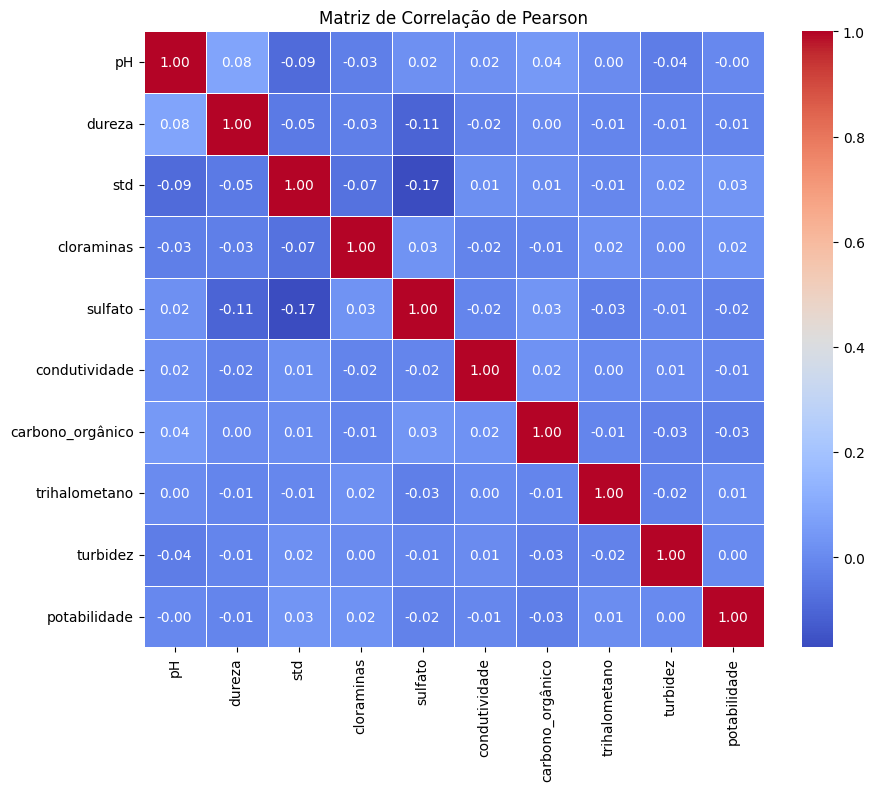

In [7]:
# Calcular correlação de Pearson
correlacao = tabela.corr(method='pearson')

# Configurar tamanho da figura
plt.figure(figsize=(10, 8))

# Criar heatmap com seaborn
sns.heatmap(
    correlacao,
    annot=True,       # mostra os valores
    cmap='coolwarm',  # paleta de cores
    fmt='.2f',        # duas casas decimais
    linewidths=0.5
)

# Título
plt.title("Matriz de Correlação de Pearson")

# Exibir gráfico
plt.show()

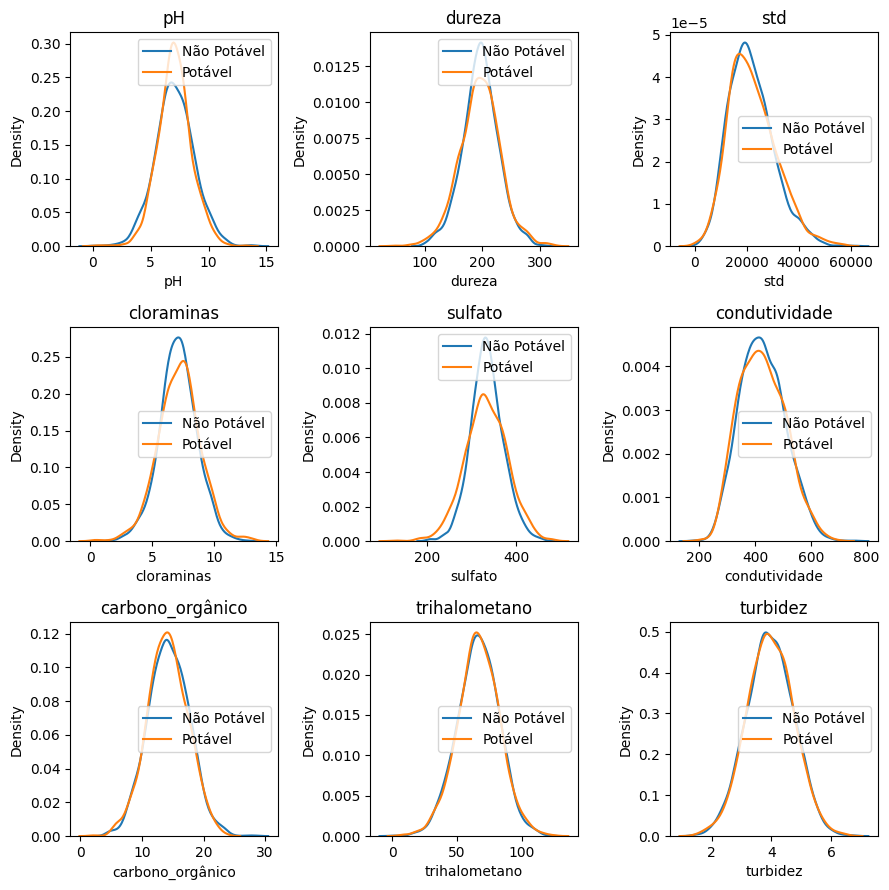

In [8]:
# Separando os grupos
nao_potavel = tabela[tabela["potabilidade"] == 0]
potavel = tabela[tabela["potabilidade"] == 1]

# Gráficos
plt.figure(figsize=(9,9))

for ax, col in enumerate(tabela.columns[:9]):
    plt.subplot(3,3, ax + 1)
    
    plt.title(col)
    
    sns.kdeplot(
        x=nao_potavel[col],
        label="Não Potável"
    )
    
    sns.kdeplot(
        x=potavel[col],
        label="Potável"
    )
    
    plt.legend()

plt.tight_layout()
plt.show()

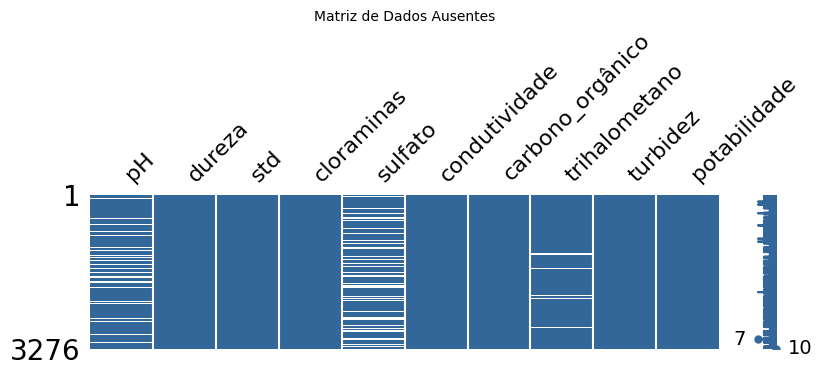

In [9]:
msno.matrix(tabela, figsize=(9, 2), color=(0.2, 0.4, 0.6))

plt.title("Matriz de Dados Ausentes", fontsize=10)
plt.show()

In [10]:
tabela.isnull().sum()

pH                  491
dureza                0
std                   0
cloraminas            0
sulfato             781
condutividade         0
carbono_orgânico      0
trihalometano       162
turbidez              0
potabilidade          0
dtype: int64

In [11]:
#tabela.iloc[:, :-1] = tabela.iloc[:, :-1].fillna(tabela.groupby("potabilidade").transform("mean"))

In [13]:
tabela['pH'] = tabela['pH'].fillna(tabela['pH'].mean())
tabela['sulfato'] = tabela['sulfato'].fillna(tabela['sulfato'].mean())
tabela['trihalometano'] = tabela['trihalometano'].fillna(tabela['trihalometano'].mean())

In [14]:
tabela.isnull().sum()

pH                  0
dureza              0
std                 0
cloraminas          0
sulfato             0
condutividade       0
carbono_orgânico    0
trihalometano       0
turbidez            0
potabilidade        0
dtype: int64

In [15]:
if len(tabela) > 0:
    tabela.to_csv('../data/02-processed/dados-agua-tratados.csv',index=False)
else:
    print(f'Aruivo não salvo')